In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

import astropy as ap
from astropy.table import Table, join
from astropy.convolution import convolve, Gaussian1DKernel

from desitarget import targetmask

from sparcl.client import SparclClient
from dl import queryClient as qc, authClient as ac

import jdaviz

In [38]:
settings = {
    # 'font.size':16,
    # 'axes.linewidth':2.0,
    # 'xtick.major.size':6.0,
    # 'xtick.minor.size':4.0,
    # 'xtick.major.width':2.0,
    # 'xtick.minor.width':1.5,
    'xtick.direction':'in', 
    'xtick.minor.visible':True,
    'xtick.top':True,
    # 'ytick.major.size':6.0,
    # 'ytick.minor.size':4.0,
    # 'ytick.major.width':2.0,
    # 'ytick.minor.width':1.5,
    'ytick.direction':'in', 
    'ytick.minor.visible':True,
    'ytick.right':True
}

plt.rcParams.update(**settings)

color = "#f86588"

### Query objects with Sparcl

In [39]:
client = SparclClient()
client

(sparclclient:1.2.6, api:12.0, https://astrosparcl.datalab.noirlab.edu/sparc, client_hash=, verbose=False, connect_timeout=1.1, read_timeout=5400.0, announcement=True)

In [40]:
# output fields
out = ['sparcl_id', 'specid', 'ra', 'dec', 'redshift']

# constraints for query
# constraints = {'spectype':['GALAXY'], 'ra':[208.4, 210.2], 'dec':[4.8, 6.4], 'specprimary': [True], 'data_release': ['DESI-DR1'], 'redshift': [0.1, 0.15]}
constraints = {'spectype':['QSO'], 'specprimary': [True], 'data_release': ['DESI-DR1'], 'redshift': [1,1.5]}

desi_results = client.find(outfields=out, constraints=constraints, limit=50)
desi_results

Find Results: 50 records

In [41]:
desi_results[1]

{'redshift': 1.3134145591460809,
 'specid': 39627730785930369,
 'dec': -2.339291942255427,
 'ra': 24.849208636726733,
 'sparcl_id': '00002af0-8768-11ef-a05f-525400f334e1',
 '_dr': 'DESI-DR1'}

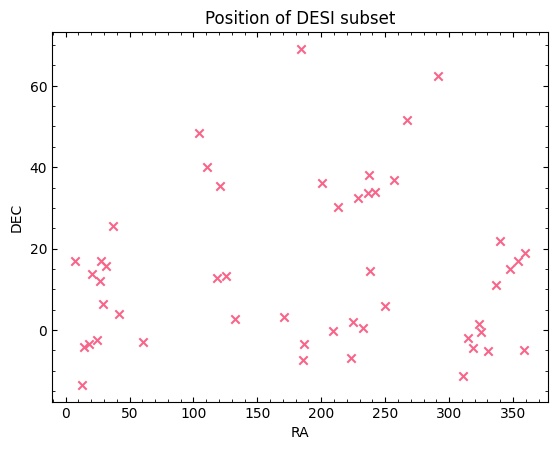

In [42]:
# extract right ascension and declination
ra = np.array([elem["ra"] for elem in desi_results.records])
dec = np.array([elem["dec"] for elem in desi_results.records])

# plot
plt.scatter(ra,dec,color=color,marker="x")

plt.title("Position of DESI subset")
plt.xlabel("RA")
plt.ylabel("DEC")

plt.show()

#### Query and plot spectra

In [43]:
# IDs of previously queried objects
idxs = np.array([str(elem["sparcl_id"]) for elem in desi_results.records])

# subset of what is to be retrieved
sel = ['wavelength', 'flux', 'ivar', 'model', 'sparcl_id', 'survey']

desi_spectra = client.retrieve(uuid_list=idxs, include=sel)

In [44]:
desi_spectra[1]

{'sparcl_id': UUID('00002af0-8768-11ef-a05f-525400f334e1'),
 'survey': 'main',
 'flux': array([1.23837128e+01, 1.47537937e+01, 1.59771891e+01, ...,
        7.62346238e-02, 6.76417470e-01, 1.57766324e-02]),
 'wavelength': array([3600. , 3600.8, 3601.6, ..., 9822.4, 9823.2, 9824. ]),
 'ivar': array([ 0.14193001,  0.11455997,  0.08380998, ..., 12.10043907,
        16.51986694, 21.2431469 ]),
 'model': array([1.54496992, 2.16535687, 2.30682683, ..., 0.67659217, 0.64747363,
        0.44771218]),
 '_dr': 'DESI-DR1'}

In [45]:
desi_table = join(desi_results.records, desi_spectra.records)
# desi_table

In [46]:
def adjust_redshift(table_row):
    wavelength = table_row["wavelength"]
    flux = table_row["flux"]
    # ivar = table_row["ivar"]

    z = table_row["redshift"]

    wavelength = wavelength/(1+z)
    flux = flux*(1+z)
    # ivar = ivar/((1+z)**2)
    
    return (wavelength, flux)

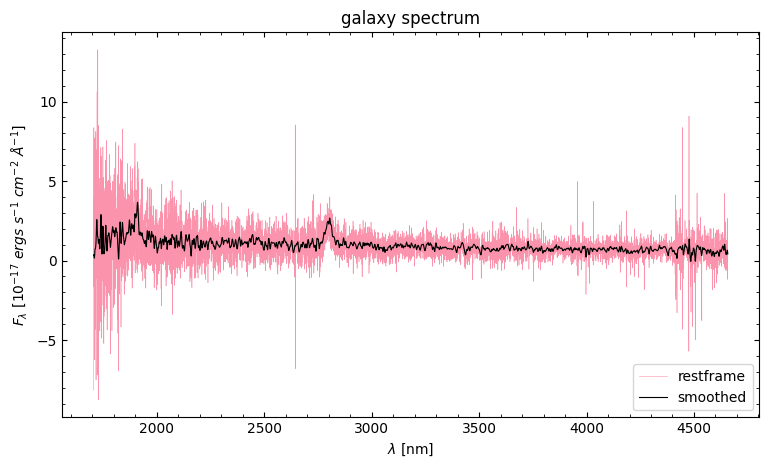

In [47]:
i = 20

lam, flux = adjust_redshift(desi_table[i])

plt.subplots(figsize=(9,5))

# plt.plot(desi_table[i]["wavelength"], desi_table[i]["flux"], linewidth=0.4, color="gray", label="redshifted", alpha=0.7)

plt.plot(lam, flux, linewidth=0.4, color=color, label="restframe", alpha=0.7)
plt.plot(lam, convolve(flux, Gaussian1DKernel(5)), linewidth=0.8, color="black", label="smoothed")

plt.title("galaxy spectrum")
plt.xlabel(r"$\lambda$ [nm]")
plt.ylabel(r"$F_{\lambda}~[10^{-17}~ergs~s^{-1}~cm^{-2}~{\AA}^{-1}]$")
plt.legend(loc="lower right")

plt.show()

### Queries with Data Lab QueryClient

In [48]:
# get overview of structure of DESI DR1
print(qc.schema('desi_dr1'))


Schema: desi_dr1

      Table Name   Description
      ----------   -----------
          agnqso   Value-Added Catalog of DESI DR1 galaxies and quasars with 
                   spectral and infrared classification diagnostics (17,995,5
                   99 rows)
        exposure   Summary quantities for every DESI exposure (9,176 rows)
     fiberassign   Quantities obtained when a DESI target is assigned to a fi
                   ber (25,061,082 rows)
           frame   Summary quantities for each petal of the DESI instrument i
                   n a given exposure; in normal operation there are ten fram
                   es for every exposure (269,960 rows)
             mws   Milky Way Survey Value-Added Catalog (6,372,607 rows)
      photometry   Photometric quantities from LS DR9 for every TARGETID (76,
                   001,458 rows)
       potential   For a given tile, this table lists all targets that could 
                   have received a fiber assignment (168,392,774 ro

In [49]:
# get overview of attributes of the spectra that are coadded by HEALPixel, i.e. by object, not by tile (ztile)
print(qc.schema('desi_dr1.zpix'))


Schema: desi_dr1
 Table: zpix

     Column Name   Description
     -----------   -----------
         coeff_5   Redrock template coefficients
               z   Redshift measured by Redrock
            zerr   Redshift error from Redrock
            chi2   Best fit chi squared
         coeff_0   Redrock template coefficients
         coeff_1   Redrock template coefficients
         coeff_2   Redrock template coefficients
         coeff_3   Redrock template coefficients
         coeff_4   Redrock template coefficients
         coeff_6   Redrock template coefficients
         coeff_7   Redrock template coefficients
         coeff_8   Redrock template coefficients
         coeff_9   Redrock template coefficients
       deltachi2   Delta-chi-squared for template fit from Redrock
   mean_fiber_ra   Mean (over exposures) RA of actual fiber position
  mean_fiber_dec   Mean (over exposures) DEC of actual fiber position
            elon   Ecliptic longitude
            elat   Ecliptic latitude


In [50]:
query = """
        SELECT zp.targetid, zp.survey, zp.program, zp.desi_target, zp.mean_fiber_ra, zp.mean_fiber_dec, zp.z, zp.zwarn, zp.spectype
        FROM desi_dr1.zpix as zp
        WHERE (zp.survey='main') AND zp.main_primary AND (zp.z BETWEEN 1 AND 3) AND (zp.zwarn=0) AND (zp.random_id BETWEEN 13 AND 23)
        LIMIT 10000
        """
# you can also use (zp.random_id BETWEEN x AND y) with x,y in [0,100] to subselect

In [66]:
zpix_cat = qc.query(sql=query, fmt="table")
zpix_cat

targetid,survey,program,desi_target,mean_fiber_ra,mean_fiber_dec,z,zwarn,spectype
int64,str4,str6,int64,float64,float64,float64,int64,str6
39628172827822526,main,dark,917542,17.33123461496143,16.32301656296159,1.528653603980422,0,GALAXY
39627684854105821,main,dark,655394,164.8189217631781,-4.359802549328504,1.550629405318019,0,GALAXY
39627701228673219,main,dark,262148,62.30499490331067,-3.463449132455652,2.214317355619338,0,QSO
39627689056801641,main,dark,4611686018427650052,55.80602823151492,-4.052582338429589,1.366122913369521,0,QSO
39627629078254594,main,dark,65537,68.08330217007813,-6.410848647154951,1.038669003790574,0,GALAXY
39633026077954377,main,dark,4611686018427387904,271.6235332102125,37.1542347098308,1.172506060245182,0,GALAXY
39627897404658597,main,dark,917542,239.3927561484309,4.529524427596659,1.209642746733489,0,GALAXY
39633025281036315,main,dark,4611686018427388932,212.2387605131892,37.25535109997185,1.329687222590388,0,QSO
39633004758303477,main,dark,2594,128.7144676563532,36.1455512858929,1.589693588138376,0,GALAXY


In [67]:
desi_mask = targetmask.desi_mask
desi_mask

desi_mask:
  - [LRG,              0, "LRG", {'obsconditions': 'DARK', 'priorities': {'UNOBS': 3200, 'MORE_ZGOOD': 2, 'MORE_ZWARN': 2, 'DONE': 2, 'OBS': 1, 'DONOTOBSERVE': 0, 'MORE_MIDZQSO': 0, 'LY_1B_ELG': 1, 'MORE_NOB1': 1, 'MORE_NOB2': 1, 'MORE_NOB3': 1}, 'numobs': 2}]
  - [ELG,              1, "ELG", {'obsconditions': 'DARK', 'priorities': {'UNOBS': 3000, 'LY_1B_ELG': 3340, 'MORE_ZGOOD': 2, 'MORE_ZWARN': 2, 'DONE': 2, 'OBS': 1, 'DONOTOBSERVE': 0, 'MORE_MIDZQSO': 0, 'MORE_NOB1': 1, 'MORE_NOB2': 1, 'MORE_NOB3': 1}, 'numobs': 2}]
  - [QSO,              2, "QSO", {'obsconditions': 'DARK', 'priorities': {'UNOBS': 3400, 'MORE_ZGOOD': 3350, 'MORE_ZWARN': 3300, 'MORE_MIDZQSO': 100, 'DONE': 2, 'OBS': 1, 'DONOTOBSERVE': 0, 'LY_1B_ELG': 1, 'MORE_NOB1': 1, 'MORE_NOB2': 1, 'MORE_NOB3': 1}, 'numobs': 4}]
  - [LGE,              3, "LRG for DESI extension", {'obsconditions': 'DARK1B', 'priorities': {'UNOBS': 3210, 'MORE_ZGOOD': 2, 'MORE_ZWARN': 2, 'DONE': 2, 'OBS': 1, 'DONOTOBSERVE': 0, 'MORE_MIDZQ

In [54]:
desi_target = zpix_cat["desi_target"]

is_lrg = (desi_target & desi_mask["LRG"] != 0)  # bitwise & operation
is_qso = (desi_target & desi_mask["QSO"] != 0)

lrg_qso_table = zpix_cat[is_lrg & is_qso]

# lrg_qso_table

In [55]:
target_idxs = [int(x) for x in lrg_qso_table["targetid"]]

inc = ['specid', 'redshift', 'flux', 'wavelength', 'spectype', 'specprimary', 'survey', 'data_release', 'targetid', 'redshift_warning', 'desi_target']  # what to include

spectra_res = client.retrieve_by_specid(specid_list=target_idxs, include=inc, dataset_list=["DESI-DR1"])

In [ ]:
spectra_pl = pl.DataFrame(spectra_res.data[1:])
spectra_pl

targetid,specprimary,redshift,specid,data_release,redshift_warning,spectype,survey,desi_target,flux,wavelength,_dr
i64,bool,f64,i64,str,i64,str,str,i64,list[f64],list[f64],str
39627790064030317,true,2.312277,39627790064030317,"""DESI-DR1""",0,"""QSO""","""main""",4611686018428895367,"[-0.871256, -0.942487, … 0.557891]","[3600.0, 3600.8, … 9824.0]","""DESI-DR1"""
39627703615230990,true,1.014982,39627703615230990,"""DESI-DR1""",0,"""QSO""","""main""",327685,"[8.200107, 0.686398, … 2.784223]","[3600.0, 3600.8, … 9824.0]","""DESI-DR1"""
39627917835110743,true,1.231184,39627917835110743,"""DESI-DR1""",0,"""QSO""","""main""",4611686018427715589,"[5.944355, -2.45612, … 1.79685]","[3600.0, 3600.8, … 9824.0]","""DESI-DR1"""
39627917759610984,true,1.016526,39627917759610984,"""DESI-DR1""",0,"""QSO""","""main""",4611686018428370983,"[6.373223, 11.06706, … 0.0]","[3600.0, 3600.8, … 9824.0]","""DESI-DR1"""
39628486503040787,true,1.567849,39628486503040787,"""DESI-DR1""",0,"""GALAXY""","""main""",327685,"[5.069628, 1.241794, … 0.484949]","[3600.0, 3600.8, … 9824.0]","""DESI-DR1"""
…,…,…,…,…,…,…,…,…,…,…,…
39628137327236165,true,1.660623,39628137327236165,"""DESI-DR1""",0,"""GALAXY""","""main""",4611686018427715589,"[2.799724, 1.630246, … 1.064084]","[3600.0, 3600.8, … 9824.0]","""DESI-DR1"""
39627732635616283,true,1.032802,39627732635616283,"""DESI-DR1""",0,"""QSO""","""main""",4611686018427715589,"[-9.460814, 3.680481, … 0.394329]","[3600.0, 3600.8, … 9824.0]","""DESI-DR1"""
39633166520025774,true,1.186402,39633166520025774,"""DESI-DR1""",0,"""QSO""","""main""",1285,"[11.281929, -1.237052, … 1.917758]","[3600.0, 3600.8, … 9824.0]","""DESI-DR1"""


### Query using selfmade function

In [1]:
from utility.retrieve_desi_spectra import retrieve_desi_spectra
from utility.plot_spectrum import plot_spectrum

In [ ]:
query = """
        SELECT zp.targetid, zp.survey, zp.program, zp.desi_target, zp.z, zp.zwarn, zp.spectype
        FROM desi_dr1.zpix as zp
        WHERE (zp.survey='main') AND zp.main_primary AND (zp.z BETWEEN 1 AND 3) AND (zp.zwarn=0) AND (zp.random_id BETWEEN 13 AND 23)
        LIMIT 300
        """

output_fields = ['specid', 'redshift', 'flux', 'wavelength', 'spectype', 'specprimary','survey', 'data_release', 'targetid', 'redshift_warning', 'desi_target']

target_mask = ["QSO"]

In [ ]:
spectra = retrieve_desi_spectra(query, output_fields, target_mask)

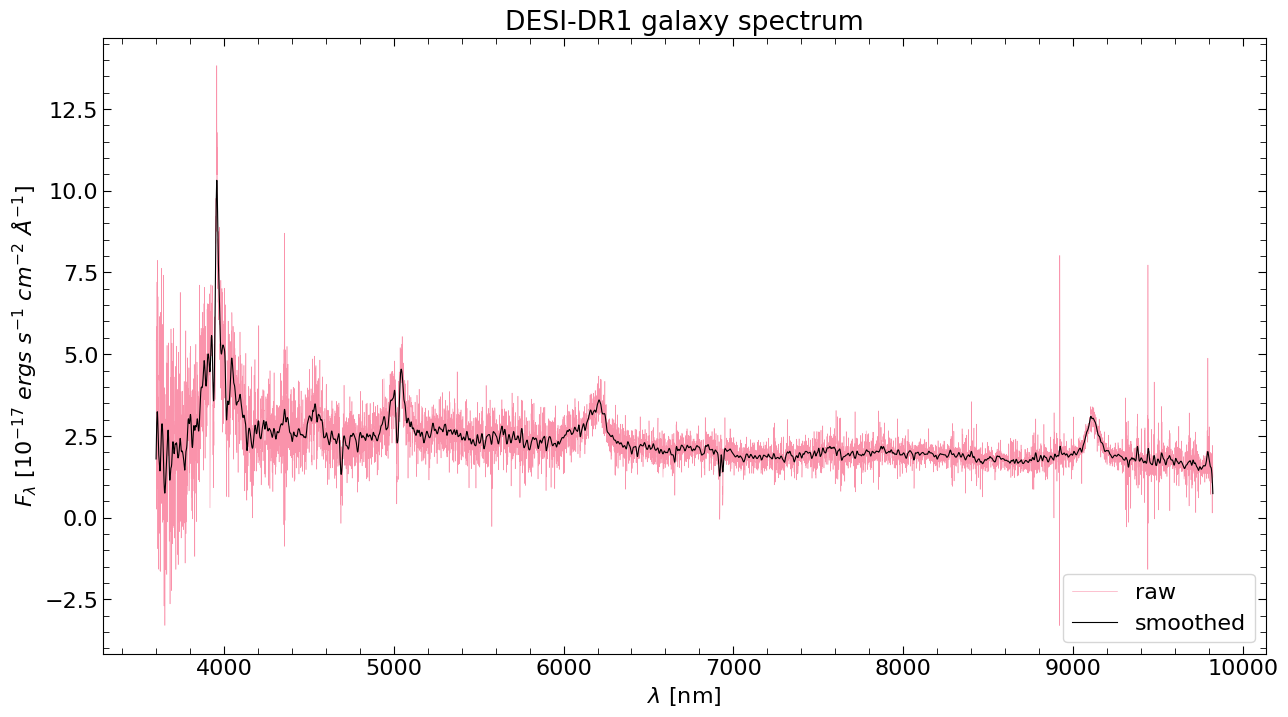

In [ ]:
idx = 0

lam = spectra[idx]["wavelength"].to_list()[0]
flux = spectra[idx]["flux"].to_list()[0]

plot_spectrum(lam, flux)